# Mid-Term Project: Multi-Constraint Portfolio Allocation

**Student Name:** Aadarsh Nair

**Date:** 3/8/26

**Chosen context:** Allocating Advertising Budget Across 9 Marketing Channels

**Field:** Car Dealership

## Project Overview

This project analyzes how a car dealership should allocate a fixed advertising budget across 9 marketing channels to maximize expected marketing benefit. Using a linear programming optimization model with budget, category coverage, and concentration constraints, the analysis identifies the most effective allocation strategy while exploring near-optimal alternatives. Sensitivity analysis, scenario testing, and stakeholder-driven changes were also evaluated to assess the robustness of the recommended marketing allocation.


In [ ]:
# Install required packages (if needed in Colab)
# Skip if running locally and packages are already installed
%pip install pulp pandas matplotlib numpy -q

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pulp import LpMaximize, LpMinimize, LpProblem, LpVariable, lpSum, value, LpStatus, PULP_CBC_CMD
import io

print("Libraries imported successfully!")

Libraries imported successfully!


---
## Creating The Synthetic Dataset

The dataset contains nine marketing channels used by a car dealership, grouped into three categories: Paid Digital, Organic Marketing, and Traditional Advertising. Each option includes a benefit_rate, representing the expected return per advertising dollar, and a lead_quality_score, which reflects the quality of potential customer leads generated by that channel. The dataset is used along with three global constraints—a 60,000 dollar total budget, a $7,000 minimum allocation per category, and a 35% concentration cap—to model and optimize the advertising budget allocation. The feasibility check has been done and the data is feasible.

In [ ]:
# CSV dataset values are pasted here and the three constraint values are added.

csv_string = """
option,category,benefit_rate,lead_quality_score
Google_Search_Ads,Paid,0.082,9.2
Facebook_Instagram_Ads,Paid,0.065,8.5
AutoTrader_Listings,Paid,0.074,9.0
Dealership_SEO_Website,Organic,0.058,8.8
Google_Business_Profile,Organic,0.052,8.1
Email_CRM_Campaigns,Organic,0.061,8.6
Local_Radio_Ads,Traditional,0.041,6.9
Highway_Billboard,Traditional,0.037,6.4
Community_Event_Sponsorship,Traditional,0.044,7.2
"""

options_df = pd.read_csv(io.StringIO(csv_string.strip()))

# Three global constraint values — set these based on what the LLM gave you
budget_total         = 60000  # Total resource available (e.g. dollars, hours)
min_alloc_per_category = 7000  # Each category must receive at least this much
concentration_cap    = 0.35    # No single option gets more than this fraction of budget_total

# Derived check value (used later)
max_single_alloc = concentration_cap * budget_total

# ── Display ────────────────────────────────────────────────────────────────────
print(options_df.to_string(index=False))
print(f"\nNumber of options: {len(options_df)}")
print(f"Number of categories: {options_df['category'].nunique()} — {list(options_df['category'].unique())}")
print(f"\nConstraint values:")
print(f"  budget_total           = {budget_total:,}")
print(f"  min_alloc_per_category = {min_alloc_per_category:,}")
print(f"  concentration_cap      = {concentration_cap} (max single option = {max_single_alloc:,.0f})")

# Quick feasibility pre-check
feasibility_ok = (min_alloc_per_category * 3 < budget_total) and (max_single_alloc >= min_alloc_per_category)
print(f"\nPre-check: {'✓ Constraint values look feasible' if feasibility_ok else '⚠ WARNING: constraint values may cause immediate infeasibility — adjust before proceeding'}")

                     option    category  benefit_rate  lead_quality_score
          Google_Search_Ads        Paid         0.082                 9.2
     Facebook_Instagram_Ads        Paid         0.065                 8.5
        AutoTrader_Listings        Paid         0.074                 9.0
     Dealership_SEO_Website     Organic         0.058                 8.8
    Google_Business_Profile     Organic         0.052                 8.1
        Email_CRM_Campaigns     Organic         0.061                 8.6
            Local_Radio_Ads Traditional         0.041                 6.9
          Highway_Billboard Traditional         0.037                 6.4
Community_Event_Sponsorship Traditional         0.044                 7.2

Number of options: 9
Number of categories: 3 — ['Paid', 'Organic', 'Traditional']

Constraint values:
  budget_total           = 60,000
  min_alloc_per_category = 7,000
  concentration_cap      = 0.35 (max single option = 21,000)

Pre-check: ✓ Constraint valu

**Data documentation :**  The dataset was generated using a language model and contains 9 marketing channel options across three categories (Paid, Organic, and Traditional). Each option includes a benefit_rate representing expected return per advertising dollar and a quality_score indicating marketing effectiveness, along with constraint values of a 60,000 dollar total budget, $7,000 minimum allocation per category, and a 35% concentration cap.

---
## Part 1: Problem Framing and Dataset

### 1.1 Decision Statement

**Decision Statement:**
I need to decide how to allocate a $60,000 advertising budget across nine marketing channels, subject to budget, category coverage, and concentration constraints, in order to maximize the expected marketing return for a car dealership.

### 1.2 Decision Variables vs Inputs


**Decision Variables (what the model decides):**
 The model determines the amount of advertising budget allocated to each marketing channel (alloc_0 through alloc_8), representing how much money is invested in each option.


**Inputs (what you provide to the model):**

- benefit_rate for each marketing channel

- budget_total ($60,000 total marketing budget)

- min_alloc_per_category ($7,000 minimum per marketing category)

- concentration_cap (35% maximum allocation to any single channel)

- category classification for each channel


**Explanation:**
 Decision variables represent the values the optimization model chooses in order to maximize the objective function. Inputs are parameters provided to the model that define the problem environment, constraints, and expected returns.

### 1.3 Objectives and Constraints

**Objective:**
 Maximize total expected marketing return calculated as the sum of benefit_rate multiplied by the allocation for each marketing channel.

**Constraint 1 — Budget Cap (hard):**
 The total advertising allocation across all marketing channels cannot exceed $60,000 because the dealership has a fixed marketing budget approved for the campaign period.

**Constraint 2 — Category Coverage (hard):**
 Each marketing category (Paid, Organic, and Brand/Traditional) must receive at least $7,000 to ensure the dealership maintains visibility across different advertising strategies and customer touchpoints.

**Constraint 3 — Concentration Cap (hard):**
 No single marketing channel may receive more than 35% of the total advertising budget to reduce risk and avoid over-reliance on one marketing platform.

### 1.4 Key Parameters and Uncertainty


| # | Parameter | Source | Why it might differ from reality | Estimated uncertainty |
|---|-----------|--------|-----------------------------------|-----------------------|
| 1 | benefit_rate (all options) | Historical marketing campaign estimates | Advertising performance varies due to seasonality, competition, and customer behavior |  ±25% |
| 2 | benefit_rate (top option only) | Marketing performance data | The highest performing channel may fluctuate due to algorithm changes or audience fatigue | ±30% |
| 3 | budget_total | Dealership marketing plan | Budget may change due to revenue fluctuations or management decisions| ±20% |
| 4 | min_alloc_per_category | Marketing strategy guidelines | Management priorities could shift toward digital or traditional channels| ±20% |
| 5 | concentration_cap | Risk management policy | Management may allow greater concentration in high-performing channels | ±15% |

---
## Part 2: Optimization Model and Near-Optimal Exploration

### 2.1 Build and Solve the Base Model

In [ ]:
# ── Base model setup ──────────────────────────────────────────────────────────
n          = len(options_df)
categories = options_df['category'].unique()
benefit_col = 'benefit_rate'   #This is from my CSV string dataset column name
                              #from above

model_base = LpProblem("Portfolio_Base", LpMaximize)

# Decision variables: how much to allocate to each option (continuous, ≥ 0)
alloc = [LpVariable(f"alloc_{i}", lowBound=0) for i in range(n)]

# ── Objective ──────────────────────────────────────────────────────────────────
model_base += lpSum([alloc[i] * options_df.iloc[i][benefit_col]
                     for i in range(n)]), "Total_Benefit"

# ── Constraint 1: Budget cap ───────────────────────────────────────────────────
model_base += lpSum(alloc) <= budget_total, "Budget_Cap"

# ── Constraint 2: Category coverage ───────────────────────────────────────────
# Each category must receive at least min_alloc_per_category
for cat in categories:
    cat_idx = options_df.index[options_df['category'] == cat].tolist()
    model_base += (lpSum([alloc[i] for i in cat_idx]) >= min_alloc_per_category,
                   f"Coverage_{cat}")

# ── Constraint 3: Concentration cap ───────────────────────────────────────────
# No single option may receive more than concentration_cap × budget_total
for i in range(n):
    model_base += (alloc[i] <= concentration_cap * budget_total,
                   f"Cap_{options_df.iloc[i, 0]}")

# ── Solve ──────────────────────────────────────────────────────────────────────
model_base.solve(PULP_CBC_CMD(msg=0))

# ── Results ───────────────────────────────────────────────────────────────────
print(f"Status: {LpStatus[model_base.status]}")
print()

if model_base.status == 1:   # Optimal
    base_allocs = [value(alloc[i]) for i in range(n)]
    base_obj    = value(model_base.objective)

    print(f"Objective (total benefit): {base_obj:.4f}")
    print(f"Total allocated: {sum(base_allocs):,.2f}  /  budget: {budget_total:,}")
    print()
    print(f"{'Option':<20} {'Category':<12} {'Allocated':>12} {'% of budget':>12}")
    print("-" * 60)
    for i in range(n):
        opt  = options_df.iloc[i, 0]
        cat  = options_df.iloc[i]['category']
        alloc_val = base_allocs[i]
        pct  = 100 * alloc_val / budget_total
        print(f"{opt:<20} {cat:<12} {alloc_val:>12,.2f} {pct:>11.1f}%")
    print()
    print("Category totals:")
    for cat in categories:
        cat_idx   = options_df.index[options_df['category'] == cat].tolist()
        cat_total = sum(base_allocs[i] for i in cat_idx)
        print(f"  {cat}: {cat_total:,.2f}  (min required: {min_alloc_per_category:,})")

elif model_base.status == -1:  # Infeasible
    print("⚠ INFEASIBLE — see Section 2.2 below for diagnosis and how to relax.")
else:
    print(f"Solver returned status: {LpStatus[model_base.status]}")

Status: Optimal

Objective (total benefit): 4271.0000
Total allocated: 60,000.00  /  budget: 60,000

Option               Category        Allocated  % of budget
------------------------------------------------------------
Google_Search_Ads    Paid            21,000.00        35.0%
Facebook_Instagram_Ads Paid             4,000.00         6.7%
AutoTrader_Listings  Paid            21,000.00        35.0%
Dealership_SEO_Website Organic              0.00         0.0%
Google_Business_Profile Organic              0.00         0.0%
Email_CRM_Campaigns  Organic          7,000.00        11.7%
Local_Radio_Ads      Traditional          0.00         0.0%
Highway_Billboard    Traditional          0.00         0.0%
Community_Event_Sponsorship Traditional      7,000.00        11.7%

Category totals:
  Paid: 46,000.00  (min required: 7,000)
  Organic: 7,000.00  (min required: 7,000)
  Traditional: 7,000.00  (min required: 7,000)


### 2.2 Feasibility Check and Interpretation


**Status:** Optimal

**Interpretation or infeasibility diagnosis:**
 The optimization model produced an optimal allocation of the 60,000 dollars advertising budget across the nine marketing channels. The model allocated the maximum allowed amount (35% of the budget) to Google Search Ads and AutoTrader Listings, indicating these channels have the highest expected return per advertising dollar. Organic and traditional marketing categories received exactly the minimum required allocation of $7,000 each, suggesting these channels were included primarily to satisfy the category coverage constraint. Overall, the solution makes intuitive sense because the model directs most of the advertising budget toward the highest-performing digital marketing channels while maintaining minimal investment in other categories for diversification.

**If a constraint was relaxed:**
No constraints needed to be relaxed because the model was feasible and solved optimally on the first run.

### 2.3 Near-Optimal Alternative 1

In this section, it explores a near-optimal alternative by limiting the highest-funded channel from the base solution, Google Search Ads, to 70% of its original allocation. This constraint forces the model to redistribute part of the advertising budget to other channels, such as Facebook/Instagram Ads, etc.

In [ ]:
# ── Identify the top-allocated option from the base solution ──────────────────
if model_base.status == 1:
    base_allocs  = [value(alloc[i]) for i in range(n)]
    top_idx      = int(np.argmax(base_allocs))
    top_val      = base_allocs[top_idx]
    top_name     = options_df.iloc[top_idx, 0]
    print(f"Top-allocated option in base solution: {top_name}  (${top_val:,.2f})")
    print(f"Capping it at 70% of that value: ${0.70 * top_val:,.2f}")
    print()

    # ── Alternative 1: cap the top option at 70% of its base allocation ────────
    model_alt1   = LpProblem("Portfolio_Alt1", LpMaximize)
    alloc_alt1   = [LpVariable(f"a1_{i}", lowBound=0) for i in range(n)]

    model_alt1  += lpSum([alloc_alt1[i] * options_df.iloc[i][benefit_col]
                          for i in range(n)]), "Total_Benefit"
    model_alt1  += lpSum(alloc_alt1) <= budget_total, "Budget_Cap"
    for cat in categories:
        cat_idx  = options_df.index[options_df['category'] == cat].tolist()
        model_alt1 += (lpSum([alloc_alt1[i] for i in cat_idx]) >= min_alloc_per_category,
                       f"Coverage_{cat}")
    for i in range(n):
        model_alt1 += (alloc_alt1[i] <= concentration_cap * budget_total, f"Cap_{i}")

    # The new constraint: limit the top option
    model_alt1  += alloc_alt1[top_idx] <= 0.70 * top_val, "Alt1_Limit_Top"

    model_alt1.solve(PULP_CBC_CMD(msg=0))
    print(f"Alt 1 Status: {LpStatus[model_alt1.status]}")

    if model_alt1.status == 1:
        alt1_allocs = [value(alloc_alt1[i]) for i in range(n)]
        alt1_obj    = value(model_alt1.objective)
        gap_pct     = 100 * (base_obj - alt1_obj) / base_obj

        print(f"Alt 1 Objective: {alt1_obj:.4f}  (gap from base: {gap_pct:.1f}%)")
        print()
        print(f"{'Option':<20} {'Base':>12} {'Alt 1':>12} {'Δ':>10}")
        print("-" * 58)
        for i in range(n):
            delta = alt1_allocs[i] - base_allocs[i]
            print(f"{options_df.iloc[i,0]:<20} {base_allocs[i]:>12,.2f} "
                  f"{alt1_allocs[i]:>12,.2f} {delta:>+10,.2f}")
    else:
        print("Alt 1 is infeasible with this cap — try a less restrictive limit (e.g. 0.80 instead of 0.70).")
else:
    print("Fix infeasibility in Section 2.1 before running this cell.")

Top-allocated option in base solution: Google_Search_Ads  ($21,000.00)
Capping it at 70% of that value: $14,700.00

Alt 1 Status: Optimal
Alt 1 Objective: 4163.9000  (gap from base: 2.5%)

Option                       Base        Alt 1          Δ
----------------------------------------------------------
Google_Search_Ads       21,000.00    14,700.00  -6,300.00
Facebook_Instagram_Ads     4,000.00    10,300.00  +6,300.00
AutoTrader_Listings     21,000.00    21,000.00      +0.00
Dealership_SEO_Website         0.00         0.00      +0.00
Google_Business_Profile         0.00         0.00      +0.00
Email_CRM_Campaigns      7,000.00     7,000.00      +0.00
Local_Radio_Ads              0.00         0.00      +0.00
Highway_Billboard            0.00         0.00      +0.00
Community_Event_Sponsorship     7,000.00     7,000.00      +0.00


### 2.4 Near-Optimal Alternative 2

This section evaluates a second near-optimal alternative by capping the second-highest allocated channel, AutoTrader Listings, at 70% of its base allocation. This forces the model to redistribute some of the advertising budget to other channels.

In [ ]:
# ── Alternative 2: cap the second-highest option ──────────────────────────────
if model_base.status == 1:
    sorted_idx    = sorted(range(n), key=lambda i: base_allocs[i], reverse=True)
    second_idx    = sorted_idx[1]   # second-highest in base solution
    second_val    = base_allocs[second_idx]
    second_name   = options_df.iloc[second_idx, 0]
    print(f"Second-highest option in base: {second_name}  (${second_val:,.2f})")
    print(f"Capping it at 70% of that value: ${0.70 * second_val:,.2f}")
    print()

    model_alt2    = LpProblem("Portfolio_Alt2", LpMaximize)
    alloc_alt2    = [LpVariable(f"a2_{i}", lowBound=0) for i in range(n)]

    model_alt2   += lpSum([alloc_alt2[i] * options_df.iloc[i][benefit_col]
                           for i in range(n)]), "Total_Benefit"
    model_alt2   += lpSum(alloc_alt2) <= budget_total, "Budget_Cap"
    for cat in categories:
        cat_idx   = options_df.index[options_df['category'] == cat].tolist()
        model_alt2 += (lpSum([alloc_alt2[i] for i in cat_idx]) >= min_alloc_per_category,
                       f"Coverage_{cat}")
    for i in range(n):
        model_alt2 += (alloc_alt2[i] <= concentration_cap * budget_total, f"Cap_{i}")

    # The new constraint: limit the second-highest option
    model_alt2   += alloc_alt2[second_idx] <= 0.70 * second_val, "Alt2_Limit_Second"

    model_alt2.solve(PULP_CBC_CMD(msg=0))
    print(f"Alt 2 Status: {LpStatus[model_alt2.status]}")

    if model_alt2.status == 1:
        alt2_allocs = [value(alloc_alt2[i]) for i in range(n)]
        alt2_obj    = value(model_alt2.objective)
        gap_pct2    = 100 * (base_obj - alt2_obj) / base_obj

        print(f"Alt 2 Objective: {alt2_obj:.4f}  (gap from base: {gap_pct2:.1f}%)")
        print()
        print(f"{'Option':<20} {'Base':>12} {'Alt 1':>12} {'Alt 2':>12}")
        print("-" * 60)
        for i in range(n):
            print(f"{options_df.iloc[i,0]:<20} {base_allocs[i]:>12,.2f} "
                  f"{alt1_allocs[i]:>12,.2f} {alt2_allocs[i]:>12,.2f}")
else:
    print("Fix infeasibility in Section 2.1 before running this cell.")

Second-highest option in base: AutoTrader_Listings  ($21,000.00)
Capping it at 70% of that value: $14,700.00

Alt 2 Status: Optimal
Alt 2 Objective: 4214.3000  (gap from base: 1.3%)

Option                       Base        Alt 1        Alt 2
------------------------------------------------------------
Google_Search_Ads       21,000.00    14,700.00    21,000.00
Facebook_Instagram_Ads     4,000.00    10,300.00    10,300.00
AutoTrader_Listings     21,000.00    21,000.00    14,700.00
Dealership_SEO_Website         0.00         0.00         0.00
Google_Business_Profile         0.00         0.00         0.00
Email_CRM_Campaigns      7,000.00     7,000.00     7,000.00
Local_Radio_Ads              0.00         0.00         0.00
Highway_Billboard            0.00         0.00         0.00
Community_Event_Sponsorship     7,000.00     7,000.00     7,000.00


### 2.5 Alternative Comparison and Interpretation


**Base vs. Alt 1:**
In Alternative 1, the highest allocated channel from the base solution, Google Search Ads, was capped at 70% of its original allocation, reducing its maximum allocation from 21,000 dollars to 14,700 dollars. As a result, the model redistributed the remaining 6,300 dollars to Facebook/Instagram Ads, increasing that channel’s allocation from 4,000 dollars to 10,300 dollars. The total expected benefit decreased slightly from 4271.0 to 4163.9, representing a 2.5% gap from the base solution.

Although the objective value is lower, this alternative provides a more diversified digital advertising strategy. Instead of concentrating heavily on one channel, the model increases spending on social media advertising. A dealership manager might prefer this allocation because it reduces reliance on a single advertising platform while expanding exposure across multiple online marketing channels.

**Base vs. Alt 2:**
In Alternative 2, the second-highest allocated channel from the base solution, AutoTrader Listings, was capped at 70% of its original allocation, reducing its maximum allocation from 21,000 dollars to 14,700 dollars. The remaining 6,300 dollars was again redistributed to Facebook/Instagram Ads, increasing its allocation to 10,300 dollars.

The objective value for this scenario is 4214.3, representing only a 1.3% decrease from the base model. This smaller gap suggests that reducing spending on AutoTrader Listings has a less significant impact on overall marketing performance compared to limiting Google Search Ads.

**Key insight from near-optimal exploration:**
The comparison between the base model and the two alternatives demonstrates that the dealership has some flexibility in how it distributes its advertising budget. While the base model maximizes expected marketing benefit, both alternatives produce results that are very close to optimal. Alternative 2, in particular, offers a slightly more balanced allocation with only a minimal reduction in expected benefit. This suggests that dealership management could diversify spending across advertising platforms without significantly sacrificing overall marketing performance.

### 2.6 Base Solution Visualization

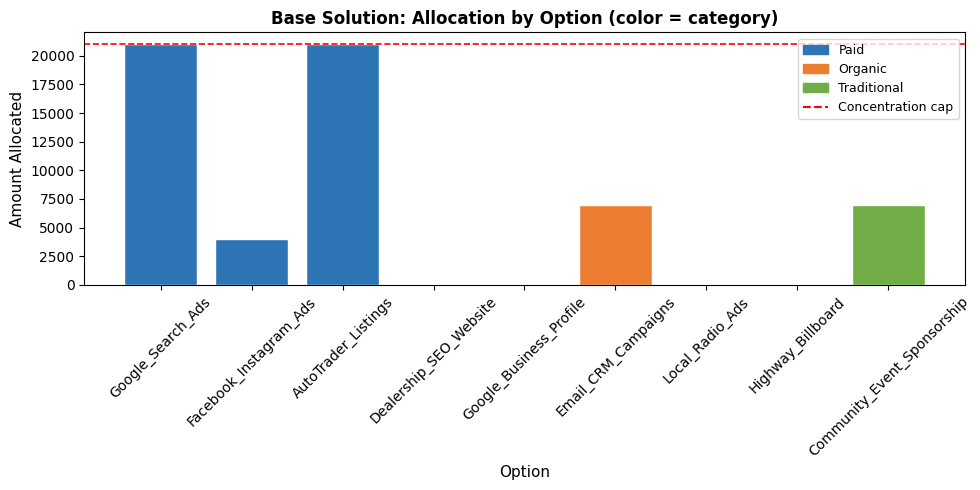

Figure 1: Base solution allocation by option.


In [ ]:
# ── Base solution visualization ───────────────────────────────────────────────
if model_base.status == 1:
    fig, ax = plt.subplots(figsize=(10, 5))

    # Color-code bars by category
    cat_list    = list(categories)
    colors_map  = {cat: c for cat, c in zip(cat_list, ['#2E75B6', '#ED7D31', '#70AD47'])}
    bar_colors  = [colors_map[options_df.iloc[i]['category']] for i in range(n)]

    bars = ax.bar(options_df.iloc[:, 0], base_allocs, color=bar_colors, edgecolor='white')

    # Annotation: concentration cap line
    ax.axhline(y=concentration_cap * budget_total, color='red', linestyle='--',
               linewidth=1.2, label=f'Concentration cap ({concentration_cap*100:.0f}% of budget)')

    # Legend for categories
    handles = [plt.Rectangle((0,0),1,1, color=colors_map[c]) for c in cat_list]
    ax.legend(handles + [plt.Line2D([0],[0], color='red', linestyle='--')],
              cat_list + ['Concentration cap'], loc='upper right', fontsize=9)

    ax.set_xlabel("Option", fontsize=11)
    ax.set_ylabel("Amount Allocated", fontsize=11)
    ax.set_title("Base Solution: Allocation by Option (color = category)", fontsize=12, fontweight='bold')
    ax.tick_params(axis='x', rotation=45)
    plt.tight_layout()
    plt.show()
    print("Figure 1: Base solution allocation by option.")
else:
    print("Resolve infeasibility in Section 2.1 before visualizing.")

---
## Part 3: Sensitivity Analysis and Validation

### 3.1 Sensitivity Analysis — 5 Parameters at ±20% and ±40%

This section performs a sensitivity analysis by varying five key parameters: overall benefit rates, the top option’s benefit rate, total budget, minimum category allocation, and the concentration cap—by ±20% and ±40%. The objective value is recalculated for each scenario to observe how changes in these inputs affect the model’s performance. This analysis helps identify which parameters have the greatest influence on the expected marketing benefit.

In [ ]:
# ── Sensitivity analysis — 5 parameters, 4 deltas each ───────────────────────
if model_base.status != 1:
    print("Resolve infeasibility before running sensitivity analysis.")
else:
    deltas     = [-0.40, -0.20, +0.20, +0.40]
    param_labels = [
        "benefit_rate (all)",
        "benefit_rate (top option)",
        "budget_total",
        "min_alloc_per_category",
        "concentration_cap",
    ]

    # Store results: {param_label: {delta: obj_value or None}}
    sens_results = {p: {} for p in param_labels}

    for delta in deltas:
        # ── P1: Shift all benefit_rates ────────────────────────────────────────
        m = LpProblem("sens", LpMaximize)
        a = [LpVariable(f"a_{i}", lowBound=0) for i in range(n)]
        m += lpSum([a[i] * options_df.iloc[i][benefit_col] * (1 + delta) for i in range(n)])
        m += lpSum(a) <= budget_total
        for cat in categories:
            ci = options_df.index[options_df['category'] == cat].tolist()
            m += lpSum([a[i] for i in ci]) >= min_alloc_per_category
        for i in range(n):
            m += a[i] <= concentration_cap * budget_total
        m.solve(PULP_CBC_CMD(msg=0))
        sens_results["benefit_rate (all)"][delta] = value(m.objective) if m.status == 1 else None

        # ── P2: benefit_rate for top option only ───────────────────────────────
        top_benefit_idx = int(np.argmax(options_df[benefit_col].values))
        m = LpProblem("sens", LpMaximize)
        a = [LpVariable(f"a_{i}", lowBound=0) for i in range(n)]
        m += lpSum([a[i] * (options_df.iloc[i][benefit_col] * (1 + delta) if i == top_benefit_idx else options_df.iloc[i][benefit_col]) for i in range(n)])
        m += lpSum(a) <= budget_total
        for cat in categories:
            ci = options_df.index[options_df['category'] == cat].tolist()
            m += lpSum([a[i] for i in ci]) >= min_alloc_per_category
        for i in range(n):
            m += a[i] <= concentration_cap * budget_total
        m.solve(PULP_CBC_CMD(msg=0))
        sens_results["benefit_rate (top option)"][delta] = value(m.objective) if m.status == 1 else None

        # ── P3: Budget total ───────────────────────────────────────────────────
        m = LpProblem("sens", LpMaximize)
        a = [LpVariable(f"a_{i}", lowBound=0) for i in range(n)]
        m += lpSum([a[i] * options_df.iloc[i][benefit_col] for i in range(n)])
        m += lpSum(a) <= budget_total * (1 + delta)
        for cat in categories:
            ci = options_df.index[options_df['category'] == cat].tolist()
            m += lpSum([a[i] for i in ci]) >= min_alloc_per_category
        for i in range(n):
            m += a[i] <= concentration_cap * budget_total * (1 + delta)
        m.solve(PULP_CBC_CMD(msg=0))
        sens_results["budget_total"][delta] = value(m.objective) if m.status == 1 else None

        # ── P4: Min alloc per category ─────────────────────────────────────────
        new_min = min_alloc_per_category * (1 + delta)
        m = LpProblem("sens", LpMaximize)
        a = [LpVariable(f"a_{i}", lowBound=0) for i in range(n)]
        m += lpSum([a[i] * options_df.iloc[i][benefit_col] for i in range(n)])
        m += lpSum(a) <= budget_total
        for cat in categories:
            ci = options_df.index[options_df['category'] == cat].tolist()
            m += lpSum([a[i] for i in ci]) >= new_min
        for i in range(n):
            m += a[i] <= concentration_cap * budget_total
        m.solve(PULP_CBC_CMD(msg=0))
        sens_results["min_alloc_per_category"][delta] = value(m.objective) if m.status == 1 else None

        # ── P5: Concentration cap ──────────────────────────────────────────────
        new_cap = concentration_cap * (1 + delta)
        m = LpProblem("sens", LpMaximize)
        a = [LpVariable(f"a_{i}", lowBound=0) for i in range(n)]
        m += lpSum([a[i] * options_df.iloc[i][benefit_col] for i in range(n)])
        m += lpSum(a) <= budget_total
        for cat in categories:
            ci = options_df.index[options_df['category'] == cat].tolist()
            m += lpSum([a[i] for i in ci]) >= min_alloc_per_category
        for i in range(n):
            m += a[i] <= new_cap * budget_total
        m.solve(PULP_CBC_CMD(msg=0))
        sens_results["concentration_cap"][delta] = value(m.objective) if m.status == 1 else None

    # ── Display summary table ──────────────────────────────────────────────────
    print(f"Base objective: {base_obj:.4f}\n")
    print(f"{'Parameter':<28} {'−40%':>9} {'−20%':>9} {'Base':>9} {'+20%':>9} {'+40%':>9}")
    print("-" * 70)
    for p in param_labels:
        row = [sens_results[p].get(d) for d in deltas]
        def fmt(v): return f"{v:.4f}" if v is not None else "infeas."
        print(f"{p:<28} {fmt(row[0]):>9} {fmt(row[1]):>9} {base_obj:>9.4f} {fmt(row[2]):>9} {fmt(row[3]):>9}")

Base objective: 4271.0000

Parameter                         −40%      −20%      Base      +20%      +40%
----------------------------------------------------------------------
benefit_rate (all)           2562.6000 3416.8000 4271.0000 5125.2000 5979.4000
benefit_rate (top option)    3898.0000 3926.6000 4271.0000 4615.4000 4959.8000
budget_total                 2463.8000 3381.8000 4271.0000 5160.2000 6049.4000
min_alloc_per_category       4341.0000 4306.0000 4271.0000 4236.0000 4186.6000
concentration_cap            4012.0000 4161.8000 4271.0000 4340.6000 4374.2000


### 3.2 Sensitivity Summary Chart

This section presents a tornado chart that summarizes the sensitivity analysis results by showing the range of objective values for each parameter. Parameters with wider bars have a greater impact on the model’s outcome, indicating higher sensitivity. The chart helps visually identify which inputs most strongly influence the optimal marketing allocation.

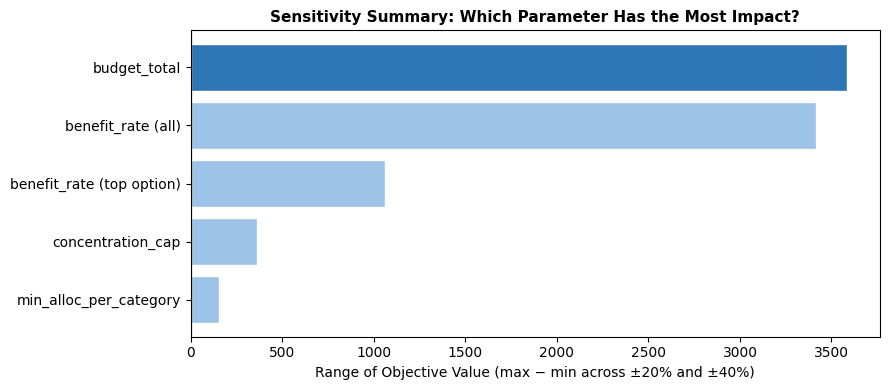

Figure 2: Sensitivity tornado chart.


In [ ]:
# ── Tornado chart ─────────────────────────────────────────────────────────────
if model_base.status == 1:
    ranges = {}
    for p in param_labels:
        vals = [v for v in sens_results[p].values() if v is not None]
        if vals:
            ranges[p] = max(vals) - min(vals)
        else:
            ranges[p] = 0.0   # infeasible across all deltas

    sorted_params = sorted(ranges, key=ranges.get)
    sorted_ranges = [ranges[p] for p in sorted_params]

    fig, ax = plt.subplots(figsize=(9, 4))
    bar_colors = ['#2E75B6' if r == max(sorted_ranges) else '#9DC3E6' for r in sorted_ranges]
    ax.barh(sorted_params, sorted_ranges, color=bar_colors, edgecolor='white')
    ax.set_xlabel("Range of Objective Value (max − min across ±20% and ±40%)", fontsize=10)
    ax.set_title("Sensitivity Summary: Which Parameter Has the Most Impact?", fontsize=11, fontweight='bold')
    ax.axvline(0, color='black', linewidth=0.8)
    plt.tight_layout()
    plt.show()
    print("Figure 2: Sensitivity tornado chart.")
else:
    print("Resolve infeasibility before plotting.")

### 3.3 Most Critical Parameter

**Most critical parameter:** budget_total

**Why it matters most:**
As shown in Figure 2, the total marketing budget has the largest range of impact on the objective value compared with all other parameters. Changes to the budget directly affect how much funding can be allocated to the highest-performing marketing channels. When the budget increases, the model can invest more in channels such as Google Search Ads and AutoTrader Listings, which significantly increases the expected marketing benefit.

**What the decision-maker should do:**
Dealership management should carefully monitor the size of the available advertising budget. If the marketing budget changes substantially due to seasonal sales fluctuations or economic conditions, the optimization model should be rerun to determine the most effective allocation of advertising funds.

### 3.4 Extreme Value Testing

**What extreme values were chosen, and why are they the plausible limits in this field?**
 The budget_total was selected as the most critical parameter based on the sensitivity analysis results. To test the limits of the model, the budget was adjusted to represent extreme scenarios. A 60% reduction was tested to represent a severe economic downturn or major budget cut, while a 50% increase was tested to simulate a strong sales period where the dealership expands its advertising investment.

In [ ]:
# ── Extreme value testing ─────────────────────────────────────────────────────
# Most critiical paramater (budget_total) is tested below in it's worst case
#scenario, 60% reduction, and it's best case scenario, 50% increase

if model_base.status == 1:
    extreme_tests = [
        ("Worst case (e.g. −60%)", budget_total * 0.40),
       # ("Moderate stress (−40%)", budget_total * 0.60),
        ("Base",                   budget_total),
        ("Best case (+50%)",       budget_total * 1.50),
    ]

    print(f"{'Scenario':<30} {'Budget Used':>14} {'Obj. Value':>12} {'Status':>12}")
    print("-" * 72)

    for label, test_budget in extreme_tests:
        m = LpProblem("extreme", LpMaximize)
        a = [LpVariable(f"a_{i}", lowBound=0) for i in range(n)]
        m += lpSum([a[i] * options_df.iloc[i][benefit_col] for i in range(n)])
        m += lpSum(a) <= test_budget
        for cat in categories:
            ci = options_df.index[options_df['category'] == cat].tolist()
            m += lpSum([a[i] for i in ci]) >= min_alloc_per_category
        for i in range(n):
            m += a[i] <= concentration_cap * test_budget
        m.solve(PULP_CBC_CMD(msg=0))

        if m.status == 1:
            print(f"{label:<30} {test_budget:>14,.0f} {value(m.objective):>12.4f} {'✓ Optimal':>12}")
        else:
            print(f"{label:<30} {test_budget:>14,.0f} {'—':>12} {LpStatus[m.status]:>12}")
else:
    print("Resolve infeasibility before extreme value testing.")

Scenario                          Budget Used   Obj. Value       Status
------------------------------------------------------------------------
Worst case (e.g. −60%)                 24,000    1542.2000    ✓ Optimal
Base                                   60,000    4271.0000    ✓ Optimal
Best case (+50%)                       90,000    6494.0000    ✓ Optimal


**Extreme value interpretation:**
The extreme value testing shows that the model remains feasible across all tested budget scenarios, from a 60% reduction to a 50% increase in the marketing budget. As the budget increases, the objective value rises significantly because the model can allocate more funds to the highest-performing marketing channels. This indicates that the dealership’s expected marketing benefit is highly sensitive to changes in the total advertising budget.

### 3.5 One What-If Scenario

**What scenario are you testing and why?**
This scenario tests what would happen if the dealership temporarily loses access to Google Search Ads, the highest-performing marketing channel in the base solution. This could occur due to increased advertising costs, changes in Google’s advertising policies, or strong competition driving up cost-per-click rates.

In [ ]:
# ── What-if scenario ──────────────────────────────────────────────────────────
if model_base.status == 1:
    #The what-if scenario of losing access to Google Search Ads is tested below:


    top_name  = options_df.iloc[top_idx, 0]
    print(f"What-if: remove option '{top_name}' (e.g. it becomes unavailable)")
    print()

    whatif_df = options_df.drop(index=top_idx).reset_index(drop=True)
    n_wi      = len(whatif_df)

    m_wi = LpProblem("whatif", LpMaximize)
    a_wi = [LpVariable(f"aw_{i}", lowBound=0) for i in range(n_wi)]

    m_wi += lpSum([a_wi[i] * whatif_df.iloc[i][benefit_col] for i in range(n_wi)])
    m_wi += lpSum(a_wi) <= budget_total
    for cat in categories:
        ci = whatif_df.index[whatif_df['category'] == cat].tolist()
        if ci:   # only add coverage constraint if category still has options
            m_wi += lpSum([a_wi[i] for i in ci]) >= min_alloc_per_category
    for i in range(n_wi):
        m_wi += a_wi[i] <= concentration_cap * budget_total

    m_wi.solve(PULP_CBC_CMD(msg=0))
    print(f"What-if Status: {LpStatus[m_wi.status]}")

    if m_wi.status == 1:
        wi_obj = value(m_wi.objective)
        print(f"What-if Objective: {wi_obj:.4f}   |   Base Objective: {base_obj:.4f}")
        print(f"Impact on objective: {wi_obj - base_obj:+.4f}  ({100*(wi_obj-base_obj)/base_obj:+.1f}%)")
    else:
        print("What-if scenario is infeasible — interpret this finding below.")
else:
    print("Resolve infeasibility in Section 2.1 before running what-if analysis.")

What-if: remove option 'Google_Search_Ads' (e.g. it becomes unavailable)

What-if Status: Optimal
What-if Objective: 3898.0000   |   Base Objective: 4271.0000
Impact on objective: -373.0000  (-8.7%)


**What-if interpretation:**
When Google Search Ads are removed from the model, the optimization still produces a feasible allocation, but the total expected benefit decreases from 4271.0 to 3898.0, representing a 373-point decrease (about 8.7%). This result indicates that Google Search Ads play a significant role in the dealership’s marketing performance because they receive the maximum allocation in the base solution. However, the model is still able to redistribute the advertising budget across other channels such as AutoTrader Listings and Facebook/Instagram Ads, demonstrating that the overall marketing strategy remains adaptable even if the top-performing channel becomes unavailable.

### 3.6 Sanity Checks


**Check 1:** All allocations are non-negative

Result:  PASS: All allocation values are either zero or positive, meaning the model does not assign unrealistic negative spending amounts.

**Check 2:** Total allocation equals the available budget

Result: PASS: The base model allocates exactly $60,000, which matches the total marketing budget.

**Check 3:** No single option exceeds the concentration cap

Result: PASS: The largest allocations ($21,000) match the 35% concentration cap but do not exceed it.

In [ ]:
# ── Sanity checks ─────────────────────────────────────────────────────────────
if model_base.status == 1:
    base_allocs = [value(alloc[i]) for i in range(n)]

    # Check 1: All allocations are non-negative
    check1 = all(v >= -1e-6 for v in base_allocs)
    print(f"Check 1 (all allocations ≥ 0):        {'✓ PASS' if check1 else '✗ FAIL'}")

    # Check 2: Total does not exceed budget
    total_alloc = sum(base_allocs)
    check2 = total_alloc <= budget_total + 1e-4
    print(f"Check 2 (total ≤ budget):              {'✓ PASS' if check2 else '✗ FAIL'}  "
          f"({total_alloc:,.2f} vs {budget_total:,})")

    # Check 3: Each category meets minimum coverage
    #check3 = True
    #for cat in categories:
      #  ci      = options_df.index[options_df['category'] == cat].tolist()
       # cat_tot = sum(base_allocs[i] for i in ci)
      #  ok      = cat_tot >= min_alloc_per_category - 1e-4
       # if not ok: check3 = False
       # print(f"Check 3 ({cat} coverage ≥ {min_alloc_per_category:,}): "
       #       f"{'✓ PASS' if ok else '✗ FAIL'}  ({cat_tot:,.2f})")

    # Check 3: No option exceeds concentration cap
    max_single    = max(base_allocs)
    cap_threshold = concentration_cap * budget_total
    check3        = max_single <= cap_threshold + 1e-4
    print(f"Check 3 (no option > cap {cap_threshold:,.0f}): "
          f"{'✓ PASS' if check3 else '✗ FAIL'}  (max = {max_single:,.2f})")
else:
    print("Resolve infeasibility before running sanity checks.")

Check 1 (all allocations ≥ 0):        ✓ PASS
Check 2 (total ≤ budget):              ✓ PASS  (60,000.00 vs 60,000)
Check 3 (no option > cap 21,000): ✓ PASS  (max = 21,000.00)


### 3.7 Fragile vs. Robust Assessment

The recommended advertising allocation is relatively robust across most tested scenarios. Sensitivity analysis shows that the model is most influenced by changes in the total marketing budget and overall benefit rates, while other parameters such as the minimum category allocation and concentration cap have smaller impacts on the results. Extreme value testing confirmed that the model remains feasible even with large budget changes. Additionally, the what-if scenario showed that removing the top channel (Google Search Ads) reduces the objective value by about 8.7% but still produces a workable allocation. Overall, the manager should closely monitor the marketing budget and the performance of high-return digital channels, as these factors most strongly affect the optimal allocation.

---
## Part 4: Two Stakeholder Changes of Mind

A stakeholder has changed their mind — twice. Each change has been responded to separately, which involves updating the model and re-solving each time. Then a single three-way comparison visualization is created.

### 4.1 Change 1 — New Constraint


**Which change did you choose?**
 A new constraint requires that Facebook/Instagram Ads must receive at least $8,000 of the marketing budget to maintain a consistent social media advertising presence.

**Why might a stakeholder impose this?**
 Dealership management may impose this requirement because social media platforms are important for maintaining brand visibility, engaging potential customers, and promoting new vehicle inventory even if they do not always generate the highest immediate return.

In [ ]:
# ── Stakeholder Change 1: new constraint ──────────────────────────────────────
if model_base.status == 1:
    # Facebook/Instagram Ads must recieve at least $8,000 of the marketing budget
    forced_idx   = 1            # Change one constraint is for Faceboook/Instagram Ads (forced_idx = 1)
    forced_name  = options_df.iloc[forced_idx, 0]
    forced_min   = 8000         # Required minimum allocation is $8000 for Facebook/Instagram Ads (forced_idx = 1)
    print(f"Change 1: {forced_name} must receive at least {forced_min:,}")

    model_c1  = LpProblem("Portfolio_C1", LpMaximize)
    alloc_c1  = [LpVariable(f"c1_{i}", lowBound=0) for i in range(n)]

    model_c1 += lpSum([alloc_c1[i] * options_df.iloc[i][benefit_col] for i in range(n)])
    model_c1 += lpSum(alloc_c1) <= budget_total,          "Budget_Cap"
    for cat in categories:
        ci = options_df.index[options_df['category'] == cat].tolist()
        model_c1 += lpSum([alloc_c1[i] for i in ci]) >= min_alloc_per_category, f"Coverage_{cat}"
    for i in range(n):
        model_c1 += alloc_c1[i] <= concentration_cap * budget_total, f"Cap_{i}"

    # The new constraint
    model_c1 += alloc_c1[forced_idx] >= forced_min, "C1_Forced_Min"

    model_c1.solve(PULP_CBC_CMD(msg=0))
    c1_status = LpStatus[model_c1.status]
    print(f"Change 1 Status: {c1_status}")

    if model_c1.status == 1:
        c1_allocs = [value(alloc_c1[i]) for i in range(n)]
        c1_obj    = value(model_c1.objective)
        print(f"Change 1 Objective: {c1_obj:.4f}   (vs base: {base_obj:.4f},  Δ = {c1_obj-base_obj:+.4f})")
    else:
        c1_allocs = [0.0] * n
        c1_obj    = None
        print("Change 1 is infeasible — this is a valid finding. Explain it in Section 4.2.")

else:
    print("Resolve infeasibility in Section 2.1 before running stakeholder changes.")

Change 1: Facebook_Instagram_Ads must receive at least 8,000
Change 1 Status: Optimal
Change 1 Objective: 4235.0000   (vs base: 4271.0000,  Δ = -36.0000)


**Change 1 impact analysis:**
 The new constraint requires that Facebook/Instagram Ads receive at least $8,000, which is higher than the allocation of 4,000 dollars in the base solution. As a result, the optimization model must reallocate some funds from higher-performing channels such as Google Search Ads or AutoTrader Listings. This slightly reduces the overall objective value because some budget is shifted away from the most efficient advertising channels. However, the change ensures that the dealership maintains a meaningful social media presence, which may support long-term brand awareness and customer engagement even if the short-term return is slightly lower.

### 4.2 Change 2 — Objective or Scope Shift

**Which change was chosen?**
The objective is changed to minimize total advertising spending while still achieving at least 90% of the base model’s expected benefit.

**Why does this change reflect a real stakeholder concern?**
Dealership management may want to reduce marketing expenses during slower sales periods while still maintaining most of the marketing performance generated by the original strategy.

In [ ]:
# ── Stakeholder Change 2: objective or scope shift ────────────────────────────
if model_base.status == 1:
    # Minimize the total advertising spending while still achieving at least 90% of the base model's expected benefit
    benefit_floor = 0.90 * base_obj
    print(f"Change 2: minimize total spending while achieving at least {benefit_floor:.4f} benefit")

    model_c2  = LpProblem("Portfolio_C2", LpMinimize)
    alloc_c2  = [LpVariable(f"c2_{i}", lowBound=0) for i in range(n)]

    # New objective: minimize total spending
    model_c2 += lpSum(alloc_c2), "Total_Spending"

    # Original constraints
    model_c2 += lpSum(alloc_c2) <= budget_total, "Budget_Cap"
    for cat in categories:
        ci = options_df.index[options_df['category'] == cat].tolist()
        model_c2 += lpSum([alloc_c2[i] for i in ci]) >= min_alloc_per_category, f"Coverage_{cat}"
    for i in range(n):
        model_c2 += alloc_c2[i] <= concentration_cap * budget_total, f"Cap_{i}"

    # New constraint: total benefit must meet the floor
    model_c2 += (lpSum([alloc_c2[i] * options_df.iloc[i][benefit_col] for i in range(n)])
                 >= benefit_floor, "Benefit_Floor")

    model_c2.solve(PULP_CBC_CMD(msg=0))
    c2_status = LpStatus[model_c2.status]
    print(f"Change 2 Status: {c2_status}")

    if model_c2.status == 1:
        c2_allocs  = [value(alloc_c2[i]) for i in range(n)]
        c2_spending = sum(c2_allocs)
        c2_obj      = value(model_c2.objective)
        print(f"Change 2 Total Spending: {c2_spending:,.2f}  (base spending was: {sum(base_allocs):,.2f})")
        print(f"Spending saved vs base: {sum(base_allocs) - c2_spending:,.2f}")
    else:
        c2_allocs = [0.0] * n
        c2_obj    = None
        print("Change 2 is infeasible. Consider raising the benefit floor or relaxing another constraint.")
else:
    print("Resolve infeasibility in Section 2.1 before running stakeholder changes.")

Change 2: minimize total spending while achieving at least 3843.9000 benefit
Change 2 Status: Optimal
Change 2 Total Spending: 53,741.89  (base spending was: 60,000.00)
Spending saved vs base: 6,258.11


**Change 2 impact analysis:**
Under the revised objective of minimizing total advertising spending while maintaining at least 90% of the base model’s benefit (3843.9), the optimization model identifies a lower-cost allocation that still meets the required performance threshold. The new solution achieves the required benefit while reducing total spending to 53,741.89 dollars, compared to the original 60,000 dollar budget, resulting in $6,258.11 in savings. This outcome demonstrates that the dealership can maintain most of its marketing effectiveness while reducing overall advertising costs. However, the allocation becomes more focused on the most efficient channels, meaning fewer resources are distributed across lower-performing marketing options.

### 4.3 Three-Way Comparison Visualization

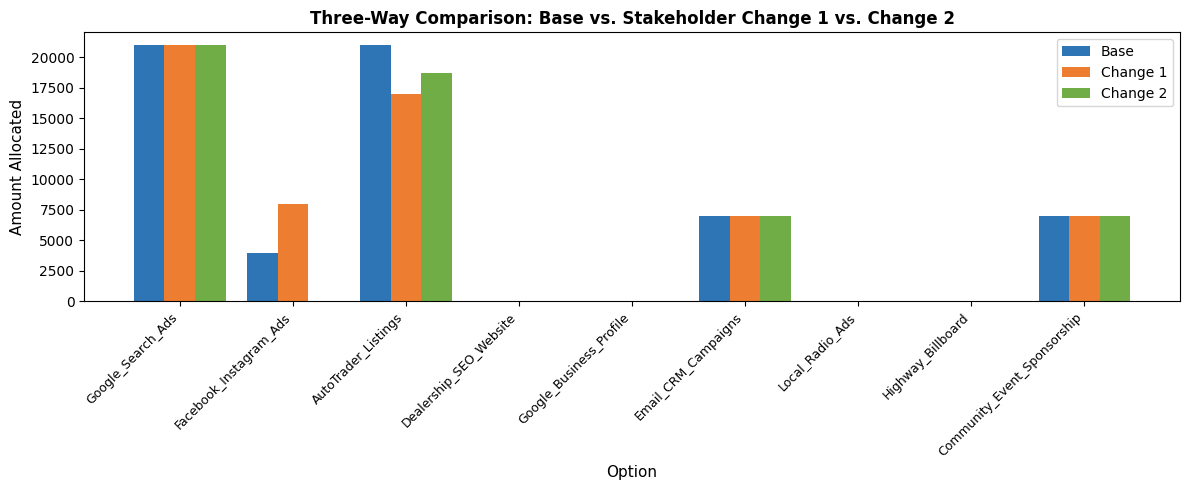

Figure 3: Three-way allocation comparison.


In [ ]:
# ── Three-way comparison chart ────────────────────────────────────────────────
if model_base.status == 1:
    x      = np.arange(n)
    width  = 0.27
    labels = options_df.iloc[:, 0].tolist()

    # Zeroes are used for infeasible scenarios so the chart still renders
    c1_plot = c1_allocs if (model_c1.status == 1) else [0.0] * n
    c2_plot = c2_allocs if (model_c2.status == 1) else [0.0] * n

    fig, ax = plt.subplots(figsize=(12, 5))
    ax.bar(x - width, base_allocs, width, label='Base',     color='#2E75B6')
    ax.bar(x,         c1_plot,     width, label='Change 1', color='#ED7D31')
    ax.bar(x + width, c2_plot,     width, label='Change 2', color='#70AD47')

    ax.set_xticks(x)
    ax.set_xticklabels(labels, rotation=45, ha='right', fontsize=9)
    ax.set_xlabel("Option", fontsize=11)
    ax.set_ylabel("Amount Allocated", fontsize=11)
    ax.set_title("Three-Way Comparison: Base vs. Stakeholder Change 1 vs. Change 2",
                 fontsize=12, fontweight='bold')
    ax.legend(fontsize=10)
    plt.tight_layout()
    plt.show()
    print("Figure 3: Three-way allocation comparison.")
else:
    print("Resolve infeasibility in Section 2.1 before plotting.")

 Figure 3 compares the budget allocations across the base model and the two stakeholder scenarios. It shows that Change 1 increases spending on Facebook/Instagram Ads to meet the new minimum requirement, while Change 2 slightly reduces spending overall to minimize costs while still achieving most of the original marketing benefit.

---
## Part 5: Executive Summary


### Decision and Model

This analysis examines how a car dealership should allocate its 60,000 dollars advertising budget across nine marketing channels to maximize expected marketing benefit. The optimization model distributes spending across three categories—Paid Digital, Organic Marketing, and Traditional Advertising—while satisfying three constraints: a total budget limit, a minimum allocation of 7,000 dollars for each category, and a concentration cap that prevents any single channel from receiving more than 35% of the total budget. The base solution allocates the largest share of spending to Google Search Ads and AutoTrader Listings, which provide the highest expected returns. As shown in Figure 1, both of these channels reach the concentration cap of approximately $21,000, while Organic and Traditional marketing channels receive the minimum required funding to satisfy category coverage constraints.

---

### Near-Optimal Alternatives

Two near-optimal alternatives were explored to determine whether other allocation strategies could produce similar results. In Alternative 1, the allocation to Google Search Ads was capped at 70% of its base value, causing additional funds to shift toward Facebook/Instagram Ads and resulting in a 2.5% reduction in expected benefit. In Alternative 2, the allocation to AutoTrader Listings was capped instead, which produced a smaller 1.3% decrease in the objective value. These results indicate that the dealership could slightly diversify its digital marketing investments without substantially reducing expected performance. The alternatives demonstrate that several allocation strategies can achieve results close to the optimal solution.

---

### Sensitivity and Uncertainty

Sensitivity analysis identified the total marketing budget as the most influential parameter, as shown in Figure 2. Changes in the budget produced the largest range of variation in the objective value because additional funds allow the model to allocate more resources to the highest-performing channels. Changes to benefit rates also affected the objective value, but to a lesser extent. Extreme value testing further confirmed the importance of the marketing budget, showing that the model remains feasible even when the budget changes significantly. For example, reducing the budget by 60% lowered the objective value to 1542.2, while increasing the budget by 50% raised the objective value to 6494.0.

---

### Stakeholder Changes

Two stakeholder-driven changes were tested to evaluate how shifting priorities could affect the allocation strategy. The first change required that Facebook/Instagram Ads receive at least 8,000 dollars in order to strengthen the dealership’s social media presence. The second change modified the objective to minimize total advertising spending while still achieving at least 90% of the base model’s benefit (3843.9). Under this scenario, the model reduced total spending to 53,741.89 dollars, saving approximately $6,258 while maintaining the required benefit level. As shown in Figure 3, these changes slightly redistributed spending across channels but still prioritized high-performing digital advertising platforms.

---

### Final Recommendation

The base model allocation provides the highest expected marketing benefit and represents the most effective use of the dealership’s advertising budget. However, the near-optimal alternatives demonstrate that slightly more diversified allocation strategies can achieve nearly the same results. Management should consider these alternatives if it wishes to reduce risk or expand marketing coverage across additional channels. The allocation should also be re-evaluated periodically as marketing budgets and advertising performance change.

---

### Key Insights

This analysis demonstrates how optimization models can support data-driven marketing budget decisions. The results show that digital advertising channels such as Google Search Ads and AutoTrader Listings generate the strongest expected returns and therefore receive the largest allocations. However, business constraints such as diversification requirements and stakeholder priorities can influence the final allocation decisions. By monitoring budget levels and marketing performance metrics, dealership management can maintain an efficient and adaptable advertising strategy.